# Multiclass classification using FeedForward Neural Networks
Implementation with Pytorch, testing on the MNIST dataset.


Pyhton 3.12.0

miriamzara@MacBook-Pro-di-Miriam MCP % python3.12 -m pip install torch 

In [1]:
import numpy as np
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## NN training

In [2]:
# --- Data ---
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])  # normalizes values from [0, 255] to [0, 1]
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform) 
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=1000)

# --- Model ---
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # input:                28x28 = 786 neurons
        # first hidden layer:   256         neurons
        # output layer:         10          neurons
        self.fc1 = nn.Linear(28*28, 256)    # creates the trainable weights (256, 28*28) and bias (256) 
        self.fc2 = nn.Linear(256, 10)       # same, creates the trainable parameters of the layer

    def forward(self, x, return_intermediate=False):
        x1 = torch.relu(self.fc1(x))  # hidden layer output
        x2 = self.fc2(x1)             # final output
        if return_intermediate:
            return x2, x1
        return x2

model = Net()                               # instantiation of the network

# --- Training setup ---
criterion = nn.CrossEntropyLoss()           # definition of the loss function
optimizer = optim.Adam(model.parameters())  # definition of the otimizer
                                            # takes as argument all the parameters of the model
                                            # which are defined in the __init__() method of class Net()

# --- Train ---
for epoch in range(3):
    for x, y in train_loader:
        optimizer.zero_grad()               # initializes gradients to zero
        loss = criterion(model(x), y)       # compute loss, comparing the current output of
                                            # the model, model(x), and the real label, y.
        loss.backward()                     # loss is not just the vector of losses. It is
                                            # a tensor that tracks the entire computation graph
                                            # that produced it. 
                                            # so you can call directly .backward() on it.
                                            # this method crosses the graph from bottom to top
                                            # computing the gradients. These gradients
                                            # are stored as attributes in the parameter objects

        optimizer.step()                    # reads the gradients and performs the update
    print(f"Epoch {epoch+1} complete")

# --- Test ---
correct = 0
total = 0
model.eval()                                # switch to evaluation mode. for instance, 
                                            # deactivate dropout - if used in the first place. 
                                            # In this very simple network, it is useless. 

with torch.no_grad():                       # avoid the automatic tracking of gradients
                                            # this saves a lot of memory and time, since you do not need it.
                                            # without no_grad(), the call model(x) would automatically
                                            # produce the computational graph.
    for x, y in test_loader:
        logits = model(x)                   # outputs of the output layer
        pred = logits.argmax(1)             # takes the class with the maximum logit 
        correct += (pred == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Accuracy: 0.9737


Comments on the code:

1. torchvision.transforms contains routines for common image transformations, including cropping, padding, rotation, color to grayscale, brightness boosting and so on. Transformations can be chained together using transforms.Compose(). Custom transformations can also applied.
2. transforms.ToTensor() Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]. PIL (Pillow, previously Python Imaging Library) is a specific format for images. 
3. x.view() reshapes a tensor. Example: 

```{python}
x = torch.randn(3, 4, 2) # total = 24 elements
x.view(12, 2) # new shape: (12,2)
x.view(4, -1) # infers the second dimension automatically, new shape: (4, 6)
x.view(-1) # infers the first dimension automatically, new shape: (24,)
```
In this usage, x.view() takes as input the image, which is a 3d tensor (height, width, n channels) and flattens it to a 1D array.

4. DataLoader() provides an iterable over the dataset. The batch size parameter specifies how many samples should be loaded at once. Pytorch methods support batch processing. This mean that in the evaluating phase you can feed the whole test dataset at once to the network - if not too big - or in batches, in general. For the training phase, the batch size is used for stochastic gradient descent computation. Smaller batch -> noisier gradient descent steps, less computationally expensive. Larger batch -> less noise, more expensive, can get stuck in local minima. 

## Weight export

```{python}

[num_layers] (int)
[sizes[0], sizes[1], ..., sizes[num_layers-1]] (ints)
Layer 0 weights (float array, row-major)
Layer 0 biases (float array)
Layer 1 weights ...
Layer 1 biases ...
...

```

In [3]:
sizes = [784, 256, 10]
state_dict = model.state_dict()


for name, param in state_dict.items():
    print(name, param.shape)


w1 = state_dict['fc1.weight'].cpu().numpy()   # weights of first fully connected layer
b1 = state_dict['fc1.bias'].cpu().numpy()     # biases of first fully connected layer
w2 = state_dict['fc2.weight'].cpu().numpy()   # second layer weights
b2 = state_dict['fc2.bias'].cpu().numpy()     # second layer biases

print("w1:\n\n", w1)
print("b1:\n\n", b1)
print("w2:\n\n", w2)
print("b2:\n\n", b2)

output_folder = "./neural_networks"
output_path = os.path.join(output_folder, "nn.bin")


size_type = np.uint64 if sys.maxsize > 2**32 else np.uint32

with open(output_path, "wb") as f:
    # wb= Writing in Binary mode
    np.array([len(sizes)], dtype=size_type).tofile(f)   # num_layers
    np.array(sizes, dtype=size_type).tofile(f)          # layer sizes
    w1.flatten().tofile(f)
    b1.flatten().tofile(f)
    w2.flatten().tofile(f)
    b2.flatten().tofile(f)

fc1.weight torch.Size([256, 784])
fc1.bias torch.Size([256])
fc2.weight torch.Size([10, 256])
fc2.bias torch.Size([10])
w1:

 [[ 0.03016851 -0.01552627  0.02615033 ... -0.02597965  0.00505177
   0.00861447]
 [-0.01449628  0.0156492   0.00731739 ... -0.0194627  -0.0058217
  -0.01969806]
 [-0.03407178  0.00315295  0.01784995 ... -0.0128094   0.02569768
   0.01973896]
 ...
 [-0.01400467  0.0227349  -0.00374303 ...  0.02965889 -0.00861759
  -0.02282704]
 [-0.03237974  0.02354002 -0.02612575 ... -0.02225754 -0.0065069
   0.02173916]
 [-0.01006912  0.00941035  0.02741207 ... -0.00797703 -0.00222588
  -0.02828964]]
b1:

 [ 8.98841098e-02  3.99271213e-02  6.73338547e-02  4.85790707e-02
  2.91020609e-03  9.84118506e-02  6.57568499e-03 -2.07977816e-02
  8.46638605e-02 -4.68913093e-02  4.67926897e-02  8.98819789e-02
  1.57259423e-02 -3.26960981e-02  6.54321536e-02  3.23988162e-02
 -3.73081747e-03 -2.05281321e-02  7.92526230e-02  2.15571299e-02
  3.90299261e-02  9.49660875e-03 -3.72922756e-02 -2.7

In [4]:
"""
import numpy as np

import sys
size_type = np.uint64 if sys.maxsize > 2**32 else np.uint32

sizes = [3, 10, 2]

weights1 = np.random.randn(10, 3)
biases1 = np.random.randn(10)

weights2 = np.random.randn(2, 10)
biases2 = np.random.randn(2)



with open("tiny_net.bin", "wb") as f:
    # wb= Writing in Binary mode
    np.array([len(sizes)], dtype=size_type).tofile(f)   # num_layers
    np.array(sizes, dtype=size_type).tofile(f)          # layer sizes
    weights1.astype(np.float32).tofile(f)
    biases1.astype(np.float32).tofile(f)
    weights2.astype(np.float32).tofile(f)
    #biases2.astype(np.float32).tofile(f)


print(size_type)
print("w1:\n", weights1)
print("b1:\n", biases1)

print("w2:\n", weights2)
print("b2:\n", biases2)
"""

'\nimport numpy as np\n\nimport sys\nsize_type = np.uint64 if sys.maxsize > 2**32 else np.uint32\n\nsizes = [3, 10, 2]\n\nweights1 = np.random.randn(10, 3)\nbiases1 = np.random.randn(10)\n\nweights2 = np.random.randn(2, 10)\nbiases2 = np.random.randn(2)\n\n\n\nwith open("tiny_net.bin", "wb") as f:\n    # wb= Writing in Binary mode\n    np.array([len(sizes)], dtype=size_type).tofile(f)   # num_layers\n    np.array(sizes, dtype=size_type).tofile(f)          # layer sizes\n    weights1.astype(np.float32).tofile(f)\n    biases1.astype(np.float32).tofile(f)\n    weights2.astype(np.float32).tofile(f)\n    #biases2.astype(np.float32).tofile(f)\n\n\nprint(size_type)\nprint("w1:\n", weights1)\nprint("b1:\n", biases1)\n\nprint("w2:\n", weights2)\nprint("b2:\n", biases2)\n'

## Forward pass 
To later compare with the manually implemented c++ version

Label =  7
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.000

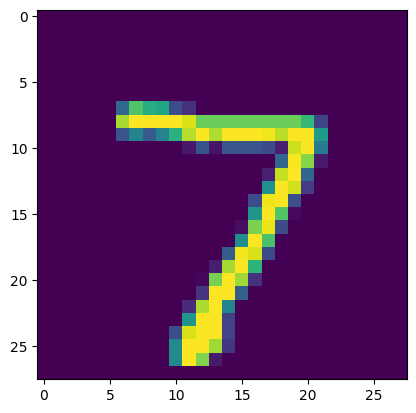

In [5]:
import matplotlib.pyplot as plt


x, y = test_set[0]
plt.imshow(x.reshape(28,28))
print("Label = ", y)
print(x)

In [6]:
output, hidden = model(x, return_intermediate=True)

print("Output (logits): \n", output, "\n")

print("Hidden layer output:\n", hidden, "\n")

Output (logits): 
 tensor([ -2.3582,  -8.2144,   0.2800,   2.2336, -11.4322,  -4.3043, -15.0200,
          9.5537,  -2.0952,  -0.6873], grad_fn=<ViewBackward0>) 

Hidden layer output:
 tensor([0.0000, 0.7637, 0.6124, 1.6312, 2.7848, 2.6245, 1.4301, 1.2120, 0.0000,
        2.2338, 0.0000, 0.0000, 0.0000, 2.0071, 0.0000, 0.0000, 0.0000, 0.8946,
        0.0000, 0.0000, 1.6157, 0.0577, 0.0000, 1.5747, 0.0000, 2.8488, 0.7276,
        0.0000, 0.0000, 1.0032, 0.0000, 1.3537, 0.0000, 0.7519, 0.3069, 1.2478,
        2.6429, 2.4992, 0.7045, 0.2654, 0.0000, 1.4285, 0.0000, 1.4183, 0.0409,
        0.0000, 0.0000, 0.3578, 0.0000, 2.5069, 0.9244, 0.0000, 0.2664, 1.7339,
        1.2592, 1.3523, 1.4418, 0.0000, 0.0000, 0.7117, 0.0000, 0.8032, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 2.6133, 2.4908,
        3.0180, 2.2523, 0.0000, 2.1757, 0.0000, 0.0000, 0.0000, 0.4249, 1.2010,
        2.4000, 1.6483, 0.0000, 0.9462, 0.4499, 0.2891, 0.2654, 0.0000, 0.7979,
        0.0000,